# Neural ground state for the 1D harmonic oscillator

This notebook is an explanatory layer over the `adjoint_qm` library. It benchmarks a parity-even Gaussian-envelope neural wavefunction against exact harmonic oscillator results.

In [28]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    src = candidate / "src"
    if src.exists():
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        break

import torch
import matplotlib.pyplot as plt

import importlib
import adjoint_qm
import adjoint_qm.ansatz
import adjoint_qm.exact_diagonalization
import adjoint_qm.estimators
import adjoint_qm.features
import adjoint_qm.potentials
import adjoint_qm.sampler
import adjoint_qm.time_evolution
import adjoint_qm.training
import adjoint_qm.vmc
importlib.reload(adjoint_qm.ansatz)
importlib.reload(adjoint_qm.exact_diagonalization)
importlib.reload(adjoint_qm.potentials)
importlib.reload(adjoint_qm.features)
importlib.reload(adjoint_qm.estimators)
importlib.reload(adjoint_qm.sampler)
importlib.reload(adjoint_qm.time_evolution)
importlib.reload(adjoint_qm.training)
importlib.reload(adjoint_qm.vmc)
importlib.reload(adjoint_qm)

from adjoint_qm import (
    EvenFeatureMap,
    GaussianEnvelopeMLP,
    HarmonicOscillatorPotential,
    QuarticOscillatorPotential,
    RadialFeatureMap,
    align_wavefunction_sign,
    diagonalize_quartic_oscillator,
    diagonalize_separable_quartic_oscillator,
    exact_harmonic_benchmarks,
    exact_isotropic_harmonic_benchmarks,
    evaluate_basis_wavefunctions,
    harmonic_correlator,
    metropolis_sample,
    normalized_wavefunction_values,
    quadrature_observables,
    quartic_oscillator_perturbation_benchmarks,
    train_quadrature,
    train_vmc_metropolis,
    trapezoid_grid,
    vmc_observables,
)

torch.set_default_dtype(torch.float64)

The ansatz is

$$
\log \psi_\theta(x) = -\frac12 \alpha x^2 + f_\theta(x^2),\qquad \alpha>0.
$$

The input feature $x^2$ enforces parity evenness, as required for the ground state of the quadratic potential.

In [7]:
omega = 1.0
torch.manual_seed(1234)

potential = HarmonicOscillatorPotential(omega=omega)
grid, weights = trapezoid_grid(x_max=8.0, n_grid=2001)
model = GaussianEnvelopeMLP(dim=1, hidden_layers=(32, 32), init_alpha=0.7)
exact = exact_harmonic_benchmarks(omega)

history = train_quadrature(
    model,
    potential,
    grid,
    weights,
    n_steps=1000,
    lr=1.0e-2,
    report_every=20,
)
obs = quadrature_observables(model, potential, grid, weights)
obs

QuadratureObservables(energy=0.5000001292922452, kinetic=0.24999795566504923, potential=0.250002173627196, norm=7.99080018159723, x2=0.500004347254392, x4=0.7500563400452678, local_energy_mean=0.5000001292922452, local_energy_variance=1.278294984017834e-06, parity_residual=0.0, virial_residual=-8.435924293559438e-06)

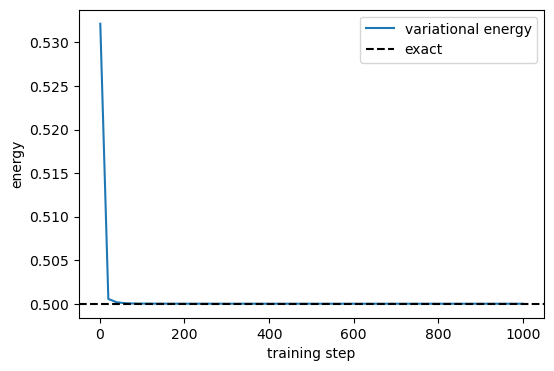

In [8]:
steps = [r.step for r in history]
energies = [r.energy for r in history]

plt.figure(figsize=(6, 4))
plt.plot(steps, energies, label="variational energy")
plt.axhline(exact["energy"], color="black", linestyle="--", label="exact")
plt.xlabel("training step")
plt.ylabel("energy")
plt.legend();

In [9]:
benchmark_table = {
    "energy": (obs.energy, exact["energy"], obs.energy - exact["energy"]),
    "x2 / G(0)": (obs.x2, exact["x2"], obs.x2 - exact["x2"]),
    "x4": (obs.x4, exact["x4"], obs.x4 - exact["x4"]),
    "local energy variance": (obs.local_energy_variance, 0.0, obs.local_energy_variance),
    "virial residual": (obs.virial_residual, 0.0, obs.virial_residual),
}
benchmark_table

{'energy': (0.5000001292922452, 0.5, 1.2929224524338423e-07),
 'x2 / G(0)': (0.500004347254392, 0.5, 4.347254392023103e-06),
 'x4': (0.7500563400452678, 0.75, 5.634004526777758e-05),
 'local energy variance': (1.278294984017834e-06, 0.0, 1.278294984017834e-06),
 'virial residual': (-8.435924293559438e-06, 0.0, -8.435924293559438e-06)}

For the exact harmonic oscillator ground state,

$$
G(\tau)=\langle x(\tau)x(0)\rangle=\frac{1}{2\omega}e^{-\omega\tau}.
$$

The learned ground state directly checks only $G(0)=\langle x^2\rangle$. Reconstructing nontrivial correlators from learned states requires excited-state wavefunctions and transition matrix elements, which is outside v1.

The correlator can also be approximated without explicitly computing excited states.  The helper below forms the source state $x\psi_0$, builds a Krylov/Lanczos approximation to $\exp[-\tau(H-E_0)]$, and evaluates $\langle x\psi_0|\exp[-\tau(H-E_0)]|x\psi_0\rangle$.

{'krylov_iterations': 8,
 'source_norm_squared / G(0)': 0.5000043472543924,
 'learned_x2': 0.500004347254392,
 'max_abs_error_vs_exact': 4.899528816881826e-06}

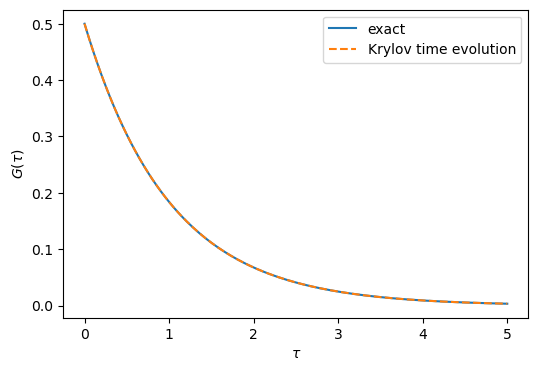

In [20]:
from adjoint_qm import dirichlet_grid_1d, krylov_spectrum, position_correlator_time_evolution_1d

tau_time = torch.linspace(0.0, 5.0, 200)
time_grid, time_weights = dirichlet_grid_1d(x_max=8.0, n_grid=1600)
g_time, time_evolution = position_correlator_time_evolution_1d(
    model,
    potential,
    time_grid,
    time_weights,
    tau_time,
    energy_shift=obs.energy,
    krylov_dim=8,
    tol=1.0e-4,
)
g_exact_time = harmonic_correlator(tau_time, omega=omega)
max_abs_error = torch.max(torch.abs(g_time - g_exact_time)).item()

plt.figure(figsize=(6, 4))
plt.plot(tau_time.numpy(), g_exact_time.numpy(), label="exact")
plt.plot(tau_time.numpy(), g_time.detach().numpy(), linestyle="--", label="Krylov time evolution")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$G(\tau)$")
plt.legend();

time_evolution_table = {
    "krylov_iterations": time_evolution.iterations,
    "source_norm_squared / G(0)": float(time_evolution.source_norm.detach() ** 2),
    "learned_x2": obs.x2,
    "max_abs_error_vs_exact": max_abs_error,
}
time_evolution_table

Diagonalizing the small Lanczos matrix gives Ritz energy estimates in the source sector.  These are not the full oscillator spectrum; they are the energies that have nonzero overlap with the source state $x\psi_0$ in this Krylov approximation.

In [21]:
spectrum = krylov_spectrum(time_evolution, energy_shift=obs.energy)

source_sector_energies = [
    {
        "ritz_index": n,
        "energy": float(spectrum.energies[n]),
        "gap_from_ground": float(spectrum.gaps[n]),
        "spectral_weight": float(spectrum.spectral_weights[n]),
        "normalized_source_weight": float(spectrum.normalized_weights[n]),
    }
    for n in range(spectrum.energies.numel())
    if spectrum.spectral_weights[n] > 1.0e-10
]
source_sector_energies

[{'ritz_index': 0,
  'energy': 1.499984503671848,
  'gap_from_ground': 0.9999843743796027,
  'spectral_weight': 0.5000041630396751,
  'normalized_source_weight': 0.9999996315737687},
 {'ritz_index': 1,
  'energy': 9.526825853443562,
  'gap_from_ground': 9.026825724151317,
  'spectral_weight': 1.8381314743804387e-07,
  'normalized_source_weight': 3.6762309857382773e-07},
 {'ritz_index': 2,
  'energy': 37.51432840955868,
  'gap_from_ground': 37.01432828026643,
  'spectral_weight': 3.98736702144097e-10,
  'normalized_source_weight': 7.97466470708959e-10}]

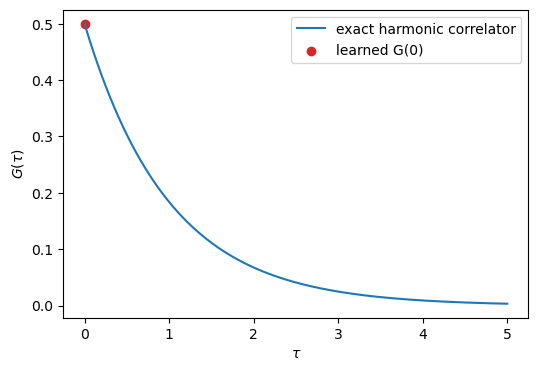

In [11]:
tau = torch.linspace(0.0, 5.0, 200)
g_tau = harmonic_correlator(tau, omega=omega)

plt.figure(figsize=(6, 4))
plt.plot(tau.numpy(), g_tau.numpy(), label="exact harmonic correlator")
plt.scatter([0.0], [obs.x2], color="tab:red", label="learned G(0)")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$G(\tau)$")
plt.legend();

## Weak quartic perturbation benchmark

The next check replaces the purely quadratic potential by the stable anharmonic oscillator

$$
H = -\frac12\frac{d^2}{dx^2} + \frac12\omega^2 x^2 + g x^4,
$$

with small positive coupling $g$.  This is no longer exactly solved by the Gaussian ansatz, so the verification is perturbative rather than exact.  For weak coupling,

$$
E_0 = \frac{\omega}{2} + \frac{3g}{4\omega^2} - \frac{21g^2}{8\omega^5} + O(g^3).
$$

The moment checks below use the corresponding first-order Hellmann--Feynman estimates for $\langle x^2\rangle$ and $\langle x^4\rangle$.

This cell trains a fresh parity-even neural wavefunction for the weak quartic potential.  The coupling is deliberately small, so perturbation theory gives a meaningful benchmark; the local-energy variance and virial residual remain diagnostics of the learned state rather than analytic proofs.

In [23]:
quartic_omega = 1.0
quartic_coupling = 0.02
torch.manual_seed(4321)

quartic_potential = QuarticOscillatorPotential(
    omega=quartic_omega,
    coupling=quartic_coupling,
)
quartic_grid, quartic_weights = trapezoid_grid(x_max=8.0, n_grid=2001)
quartic_model = GaussianEnvelopeMLP(
    dim=1,
    hidden_layers=(32, 32),
    init_alpha=1.0,
)
quartic_pt = quartic_oscillator_perturbation_benchmarks(
    omega=quartic_omega,
    coupling=quartic_coupling,
)

quartic_history = train_quadrature(
    quartic_model,
    quartic_potential,
    quartic_grid,
    quartic_weights,
    n_steps=1000,
    lr=1.0e-2,
    report_every=20,
)
quartic_obs = quadrature_observables(
    quartic_model,
    quartic_potential,
    quartic_grid,
    quartic_weights,
)
quartic_obs

QuadratureObservables(energy=0.5140864446306377, kinetic=0.26368589165795564, potential=0.25040055297268204, norm=3.886884148102685, x2=0.4742296676598874, x4=0.6642859571369182, local_energy_mean=0.5140864446306379, local_energy_variance=3.0391366990842875e-07, parity_residual=0.0, virial_residual=-7.609149296206041e-07)

This plot checks whether the variational energy approaches the perturbative weak-coupling target.  The zeroth-order line is the harmonic oscillator result; the first- and second-order lines show the perturbative correction from the $g x^4$ interaction.

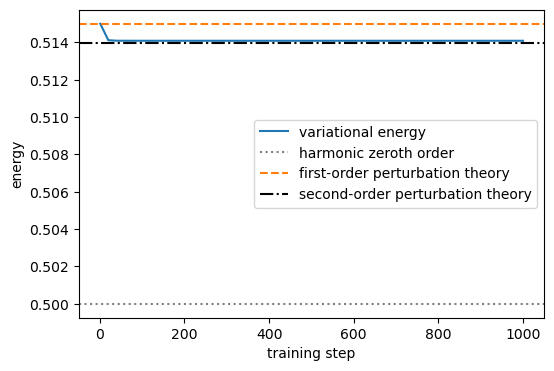

In [ ]:
quartic_steps = [r.step for r in quartic_history]
quartic_energies = [r.energy for r in quartic_history]

plt.figure(figsize=(6, 4))
plt.plot(quartic_steps, quartic_energies, label="variational energy")
plt.axhline(
    quartic_pt["energy_order0"],
    color="gray",
    linestyle=":",
    label="harmonic zeroth order",
)
plt.axhline(
    quartic_pt["energy_order1"],
    color="tab:orange",
    linestyle="--",
    label="first-order perturbation theory",
)
plt.axhline(
    quartic_pt["energy_order2"],
    color="black",
    linestyle="-.",
    label="second-order perturbation theory",
)
plt.xlabel("training step")
plt.ylabel("energy")
plt.legend();

This table records the quantitative checks.  The energy comparison uses the second-order perturbative value, while the moment comparisons use first-order perturbation theory.  The virial residual is computed as $2\langle T\rangle-\langle xV'(x)\rangle$, which is the appropriate virial theorem for the quartic potential.

In [29]:
quartic_benchmark_table = {
    "coupling g": quartic_coupling,
    "energy": (
        quartic_obs.energy,
        quartic_pt["energy_order2"],
        quartic_obs.energy - quartic_pt["energy_order2"],
    ),
    "energy first-order PT": quartic_pt["energy_order1"],
    "x2": (
        quartic_obs.x2,
        quartic_pt["x2_order1"],
        quartic_obs.x2 - quartic_pt["x2_order1"],
    ),
    "x4": (
        quartic_obs.x4,
        quartic_pt["x4_order1"],
        quartic_obs.x4 - quartic_pt["x4_order1"],
    ),
    "kinetic": quartic_obs.kinetic,
    "potential": quartic_obs.potential,
    "local energy variance": quartic_obs.local_energy_variance,
    "parity residual": quartic_obs.parity_residual,
    "virial residual": quartic_obs.virial_residual,
}
quartic_benchmark_table

{'coupling g': 0.02,
 'energy': (0.5140864446306377, 0.51395, 0.00013644463063766654),
 'energy first-order PT': 0.515,
 'x2': (0.4742296676598874, 0.47, 0.004229667659887415),
 'x4': (0.6642859571369182, 0.645, 0.019285957136918164),
 'kinetic': 0.26368589165795564,
 'potential': 0.25040055297268204,
 'local energy variance': 3.0391366990842875e-07,
 'parity residual': 0.0,
 'virial residual': -7.609149296206041e-07}

The moment plot separates the harmonic reference, the weak-coupling perturbative estimate, and the learned quadrature value.  Agreement here is a useful falsifiable check, but it should be interpreted only at weak coupling.

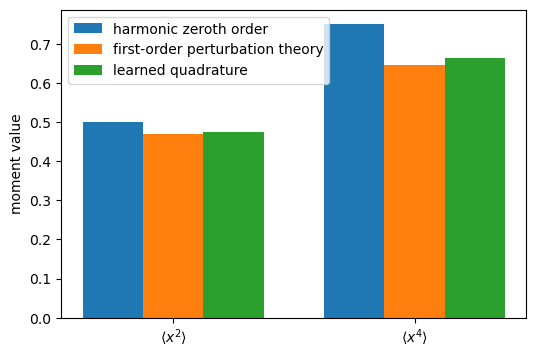

In [30]:
moment_labels = [r"$\langle x^2\rangle$", r"$\langle x^4\rangle$"]
moment_positions = torch.arange(len(moment_labels), dtype=torch.float64).numpy()
bar_width = 0.25

harmonic_moments = [quartic_pt["x2_order0"], quartic_pt["x4_order0"]]
perturbative_moments = [quartic_pt["x2_order1"], quartic_pt["x4_order1"]]
learned_moments = [quartic_obs.x2, quartic_obs.x4]

plt.figure(figsize=(6, 4))
plt.bar(
    moment_positions - bar_width,
    harmonic_moments,
    width=bar_width,
    label="harmonic zeroth order",
)
plt.bar(
    moment_positions,
    perturbative_moments,
    width=bar_width,
    label="first-order perturbation theory",
)
plt.bar(
    moment_positions + bar_width,
    learned_moments,
    width=bar_width,
    label="learned quadrature",
)
plt.xticks(moment_positions, moment_labels)
plt.ylabel("moment value")
plt.legend();

## Published exact-energy benchmark and wavefunction comparison

For a non-perturbative check, Okun and Burke, arXiv:2007.04762, study

$$
v_\lambda(x)=\frac{x^4}{4}-\lambda\frac{x^2}{2}.
$$

Their supplementary Table S1 lists exact energies to 40 digits.  The $\lambda=-1$ column is exactly our convention with $\omega=1$ and $g=1/4$:

$$
V(x)=\frac{x^2}{2}+\frac{x^4}{4}.
$$

The cell below diagonalizes the same Hamiltonian in a harmonic-oscillator basis and compares the first excited-state energies against the published table.

In [34]:
published_coupling = 0.25
published_basis_omega = 2.0
published_energies = torch.tensor(
    [
        0.6209270298257486608580357329871206982000,
        2.0259661641666569970850703427960975727209,
        3.6984503193780828535724670322135994784906,
        5.5575771385568190043356690869633769327987,
        7.5684228735599952483040236007700297795874,
        9.7091478766133491585283420979384357791199,
    ],
    dtype=torch.float64,
)

published_exact = diagonalize_quartic_oscillator(
    50,
    omega=1.0,
    coupling=published_coupling,
    basis_omega=published_basis_omega,
)

published_energy_comparison = [
    {
        "state n": n,
        "basis diagonalization": float(published_exact.energies[n]),
        "published Table S1": float(published_energies[n]),
        "difference": float(published_exact.energies[n] - published_energies[n]),
        "gap from ground": float(
            published_exact.energies[n] - published_exact.energies[0]
        ),
    }
    for n in range(published_energies.numel())
]
published_energy_comparison

[{'state n': 0,
  'basis diagonalization': 0.6209270298257487,
  'published Table S1': 0.6209270298257487,
  'difference': 0.0,
  'gap from ground': 0.0},
 {'state n': 1,
  'basis diagonalization': 2.0259661641666846,
  'published Table S1': 2.025966164166657,
  'difference': 2.7533531010703882e-14,
  'gap from ground': 1.405039134340936},
 {'state n': 2,
  'basis diagonalization': 3.6984503193780847,
  'published Table S1': 3.698450319378083,
  'difference': 1.7763568394002505e-15,
  'gap from ground': 3.077523289552336},
 {'state n': 3,
  'basis diagonalization': 5.557577138556932,
  'published Table S1': 5.557577138556819,
  'difference': 1.1368683772161603e-13,
  'gap from ground': 4.936650108731183},
 {'state n': 4,
  'basis diagonalization': 7.5684228735599985,
  'published Table S1': 7.568422873559995,
  'difference': 3.552713678800501e-15,
  'gap from ground': 6.9474958437342496},
 {'state n': 5,
  'basis diagonalization': 9.709147876613475,
  'published Table S1': 9.7091478766

This cell trains a fresh neural wavefunction at the same coupling $g=1/4$.  This is a stricter check than the weak-coupling perturbative example because the reference energy comes from direct diagonalization and a published high-precision table, not from a truncated perturbative expansion.

In [35]:
torch.manual_seed(2026)
published_potential = QuarticOscillatorPotential(
    omega=1.0,
    coupling=published_coupling,
)
published_grid, published_weights = trapezoid_grid(x_max=8.0, n_grid=2001)
published_model = GaussianEnvelopeMLP(
    dim=1,
    hidden_layers=(32, 32),
    init_alpha=1.4,
)

published_history = train_quadrature(
    published_model,
    published_potential,
    published_grid,
    published_weights,
    n_steps=1000,
    lr=1.0e-2,
    report_every=20,
)
published_obs = quadrature_observables(
    published_model,
    published_potential,
    published_grid,
    published_weights,
)

published_ground_summary = {
    "neural energy": published_obs.energy,
    "exact basis energy": float(published_exact.energies[0]),
    "published Table S1 energy": float(published_energies[0]),
    "neural minus exact": published_obs.energy - float(published_exact.energies[0]),
    "local energy variance": published_obs.local_energy_variance,
    "virial residual": published_obs.virial_residual,
}
published_ground_summary

{'neural energy': 0.6209271526984599,
 'exact basis energy': 0.6209270298257487,
 'published Table S1 energy': 0.6209270298257487,
 'neural minus exact': 1.22872711227906e-07,
 'local energy variance': 3.957782788244475e-06,
 'virial residual': 2.009327112473258e-07}

The energy plot shows the neural variational training curve against the non-perturbative reference ground energy.  The reference line is the basis-diagonalization value, which agrees with the published table at the displayed precision.

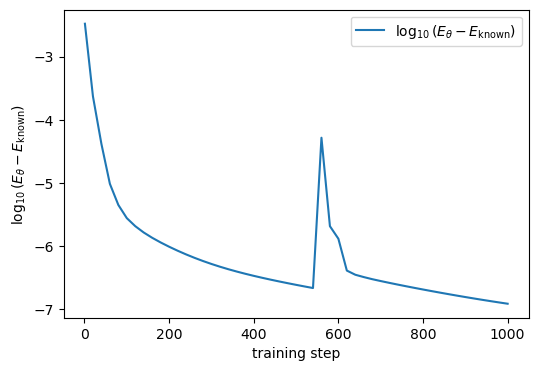

In [36]:
published_steps = [r.step for r in published_history]
published_known_energy = float(published_exact.energies[0])
published_energy_excess = torch.tensor(
    [r.energy - published_known_energy for r in published_history],
    dtype=torch.float64,
)
published_log10_excess = torch.log10(
    torch.where(
        published_energy_excess > 0.0,
        published_energy_excess,
        torch.nan,
    )
)

plt.figure(figsize=(6, 4))
plt.plot(
    published_steps,
    published_log10_excess.numpy(),
    label=r"$\log_{10}(E_\theta-E_{\rm known})$",
)
plt.xlabel("training step")
plt.ylabel(r"$\log_{10}(E_\theta-E_{\rm known})$")
plt.legend();

The wavefunction comparison normalizes the neural wavefunction on the quadrature grid and compares it with the ground-state eigenvector from the harmonic-basis diagonalization.  The exact eigenvector has an arbitrary global sign, so the plotting helper aligns its sign with the positive neural wavefunction before computing the error.

{'L2 wavefunction error': 6.289360911888395e-05,
 'max pointwise wavefunction error': 5.9423913615761186e-05}

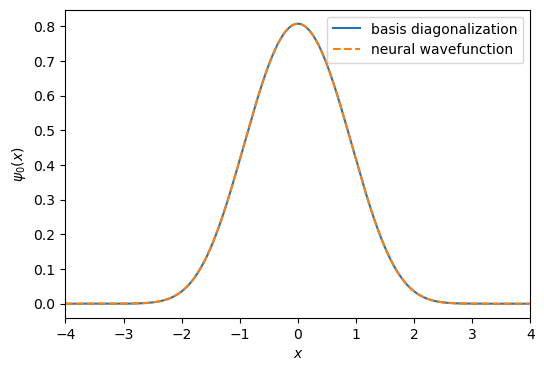

In [37]:
published_psi_nn = normalized_wavefunction_values(
    published_model,
    published_grid,
    published_weights,
)
published_psi_exact = evaluate_basis_wavefunctions(
    published_grid,
    published_exact.eigenvectors,
    basis_omega=published_exact.basis_omega,
    state_indices=[0],
).squeeze(-1)
published_psi_exact = align_wavefunction_sign(
    published_psi_exact,
    reference=published_psi_nn,
)
published_wavefunction_l2 = torch.sqrt(
    torch.sum(published_weights * (published_psi_nn - published_psi_exact) ** 2)
).item()
published_wavefunction_max_error = torch.max(
    torch.abs(published_psi_nn - published_psi_exact)
).item()

plt.figure(figsize=(6, 4))
plt.plot(
    published_grid[:, 0].numpy(),
    published_psi_exact.detach().numpy(),
    label="basis diagonalization",
)
plt.plot(
    published_grid[:, 0].numpy(),
    published_psi_nn.detach().numpy(),
    linestyle="--",
    label="neural wavefunction",
)
plt.xlim(-4.0, 4.0)
plt.xlabel(r"$x$")
plt.ylabel(r"$\psi_0(x)$")
plt.legend();

{
    "L2 wavefunction error": published_wavefunction_l2,
    "max pointwise wavefunction error": published_wavefunction_max_error,
}

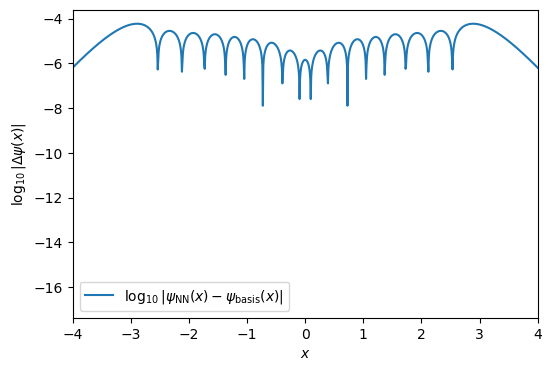

In [38]:
published_wavefunction_abs_error = torch.abs(
    published_psi_nn - published_psi_exact
)
published_wavefunction_log10_error = torch.log10(
    torch.clamp(
        published_wavefunction_abs_error,
        min=torch.finfo(published_wavefunction_abs_error.dtype).tiny,
    )
)

plt.figure(figsize=(6, 4))
plt.plot(
    published_grid[:, 0].numpy(),
    published_wavefunction_log10_error.detach().numpy(),
    label=r"$\log_{10}|\psi_{\rm NN}(x)-\psi_{\rm basis}(x)|$",
)
plt.xlim(-4.0, 4.0)
plt.xlabel(r"$x$")
plt.ylabel(r"$\log_{10}|\Delta\psi(x)|$")
plt.legend();


## Higher-dimensional Metropolis VMC benchmarks

The next cells use the basic random-walk Metropolis sampler from the library.  The harmonic oscillator check is deliberately exact: the model is the known Gaussian ground state in $D=2,4,8$, and the Monte Carlo estimates are compared with both analytic formulas and the finite-basis diagonalization of the separable Hamiltonian.


In [ ]:
multidim_omega = 1.0
multidim_dims = [2, 4, 8]
multidim_harmonic_rows = []

for dim in multidim_dims:
    harmonic_model = GaussianEnvelopeMLP(
        dim=dim,
        hidden_layers=(),
        feature_map=RadialFeatureMap(),
        init_alpha=multidim_omega,
        zero_final=True,
    )
    harmonic_potential = HarmonicOscillatorPotential(multidim_omega)
    harmonic_exact = exact_isotropic_harmonic_benchmarks(dim, multidim_omega)
    harmonic_basis = diagonalize_separable_quartic_oscillator(
        dim=dim,
        n_basis=8,
        n_levels=4,
        omega=multidim_omega,
        coupling=0.0,
        basis_omega=multidim_omega,
    )
    harmonic_samples = metropolis_sample(
        harmonic_model,
        n_samples=8192,
        dim=dim,
        n_chains=128,
        step_size=1.6 / (dim**0.5),
        burn_in=600,
        thinning=10,
        seed=7000 + dim,
    )
    harmonic_obs = vmc_observables(
        harmonic_model,
        harmonic_potential,
        harmonic_samples.samples,
    )
    multidim_harmonic_rows.append(
        {
            "dim": dim,
            "acceptance": harmonic_samples.acceptance_rate,
            "VMC energy": harmonic_obs.local_energy_mean,
            "analytic energy": harmonic_exact["energy"],
            "basis energy": float(harmonic_basis.energies[0]),
            "energy error": harmonic_obs.local_energy_mean - harmonic_exact["energy"],
            "stderr": harmonic_obs.local_energy_stderr,
            "<r^2>": harmonic_obs.x2,
            "analytic <r^2>": harmonic_exact["r2"],
            "<r^4>": harmonic_obs.r4,
            "analytic <r^4>": harmonic_exact["r4"],
            "coord variance": harmonic_obs.coordinate_variance_mean,
            "offdiag cov max": harmonic_obs.coordinate_offdiag_abs_max,
        }
    )

multidim_harmonic_rows


This plot isolates the Monte Carlo error in the harmonic benchmark.  The local energy is exactly constant for the exact Gaussian, so the energy error should be at roundoff; the nontrivial sampling checks are the moments such as $\langle r^2\rangle$ and $\langle r^4\rangle$.


In [ ]:
plt.figure(figsize=(6, 4))
plt.axhline(0.0, color="black", linewidth=1)
plt.plot(
    [row["dim"] for row in multidim_harmonic_rows],
    [row["<r^2>"] - row["analytic <r^2>"] for row in multidim_harmonic_rows],
    marker="o",
    label=r"$\langle r^2\rangle$ error",
)
plt.plot(
    [row["dim"] for row in multidim_harmonic_rows],
    [row["<r^4>"] - row["analytic <r^4>"] for row in multidim_harmonic_rows],
    marker="s",
    label=r"$\langle r^4\rangle$ error",
)
plt.xlabel(r"dimension $D$")
plt.ylabel("Monte Carlo estimate minus exact value")
plt.legend();


The quartic benchmark uses the separable potential

$$
V(x)=\frac12\omega^2\sum_i x_i^2+g\sum_i x_i^4.
$$

Because this Hamiltonian is a sum of identical one-dimensional Hamiltonians, the direct diagonalization benchmark is obtained by diagonalizing the one-dimensional quartic oscillator and summing the resulting energies.  The short VMC run below is a stochastic training smoke test, not a final precision calculation.  Larger runs should be done through `scripts/vmc_multidim_quartic.py` and loaded back into the notebook.


In [ ]:
quartic_md_omega = 1.0
quartic_md_coupling = 0.05
quartic_md_dims = [2, 4, 8]
quartic_md_histories = {}
quartic_md_rows = []

for dim in quartic_md_dims:
    torch.manual_seed(9200 + dim)
    quartic_md_model = GaussianEnvelopeMLP(
        dim=dim,
        hidden_layers=(16,),
        feature_map=EvenFeatureMap(),
        init_alpha=quartic_md_omega + 2.0 * quartic_md_coupling,
    )
    quartic_md_potential = QuarticOscillatorPotential(
        omega=quartic_md_omega,
        coupling=quartic_md_coupling,
    )
    quartic_md_exact = diagonalize_separable_quartic_oscillator(
        dim=dim,
        n_basis=32,
        n_levels=4,
        omega=quartic_md_omega,
        coupling=quartic_md_coupling,
        basis_omega=1.2,
    )
    quartic_md_history = train_vmc_metropolis(
        quartic_md_model,
        quartic_md_potential,
        dim=dim,
        n_steps=40,
        n_samples=768,
        n_chains=128,
        step_size=1.2 / (dim**0.5),
        burn_in=150,
        thinning=5,
        lr=5.0e-3,
        seed=9300 + dim,
        report_every=10,
    )
    quartic_md_eval = metropolis_sample(
        quartic_md_model,
        n_samples=4096,
        dim=dim,
        n_chains=128,
        step_size=1.2 / (dim**0.5),
        burn_in=500,
        thinning=10,
        seed=9400 + dim,
    )
    quartic_md_obs = vmc_observables(
        quartic_md_model,
        quartic_md_potential,
        quartic_md_eval.samples,
    )
    quartic_md_energy_exact = float(quartic_md_exact.energies[0])
    quartic_md_histories[dim] = {
        "history": quartic_md_history,
        "exact_energy": quartic_md_energy_exact,
    }
    quartic_md_rows.append(
        {
            "dim": dim,
            "acceptance": quartic_md_eval.acceptance_rate,
            "VMC energy": quartic_md_obs.local_energy_mean,
            "basis energy": quartic_md_energy_exact,
            "energy error": quartic_md_obs.local_energy_mean - quartic_md_energy_exact,
            "stderr": quartic_md_obs.local_energy_stderr,
            "local energy std": quartic_md_obs.local_energy_std,
            "virial residual": quartic_md_obs.virial_residual,
            "<r^2>": quartic_md_obs.x2,
            "<sum x_i^4>": quartic_md_obs.x4,
        }
    )

quartic_md_rows


The training curves show the sampled VMC energy relative to the direct-diagonalization ground energy.  The error bars in the final comparison are the naive local-energy standard error; they do not yet include autocorrelation corrections, so they should be read as a first diagnostic only.


In [ ]:
plt.figure(figsize=(6, 4))
plt.axhline(0.0, color="black", linewidth=1)
for dim, payload in quartic_md_histories.items():
    history = payload["history"]
    exact_energy = payload["exact_energy"]
    plt.plot(
        [record.step for record in history],
        [record.energy - exact_energy for record in history],
        marker="o",
        label=fr"$D={dim}$",
    )
plt.xlabel("VMC optimization step")
plt.ylabel(r"$E_{\rm VMC}-E_{\rm basis}$")
plt.legend();

plt.figure(figsize=(6, 4))
plt.axhline(0.0, color="black", linewidth=1)
plt.errorbar(
    [row["dim"] for row in quartic_md_rows],
    [row["energy error"] for row in quartic_md_rows],
    yerr=[row["stderr"] for row in quartic_md_rows],
    fmt="o",
)
plt.xlabel(r"dimension $D$")
plt.ylabel(r"final $E_{\rm VMC}-E_{\rm basis}$");
